# For showing off the various Shapes associable with Primitives

## Defining instance of each Shape

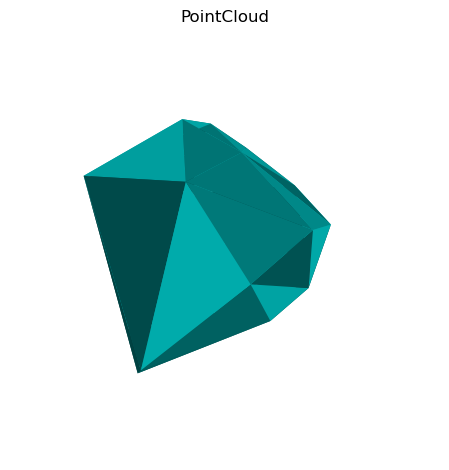

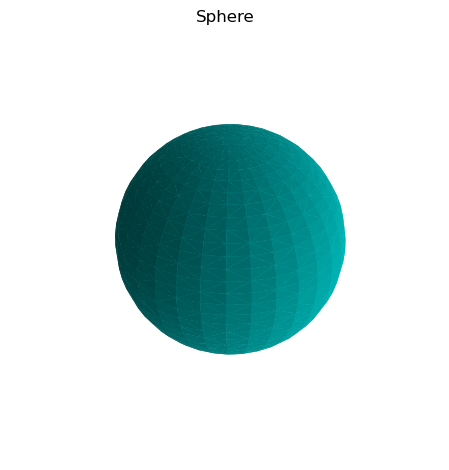

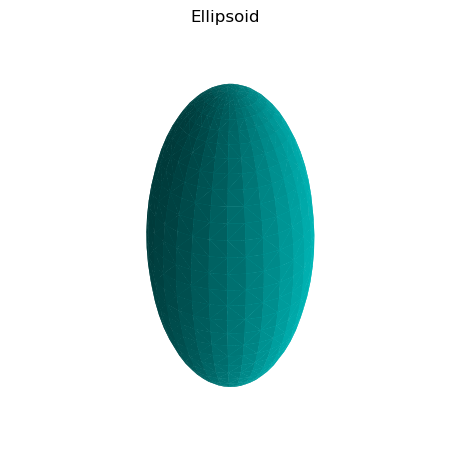

In [1]:
import numpy as np
from mupt.geometry.shapes import BoundedShape, Sphere, Ellipsoid, PointCloud, visualize_shape
# %matplotlib ipympl


# these are all the supported types of BoundedShape currently in MuPT
shapes : list[BoundedShape] = [
    PointCloud(np.random.rand(40,3)),
    Sphere(1),
    Ellipsoid.from_components(1, 1, 2),
]

for shape in shapes:
    ax = visualize_shape(shape, grid=False, color='c')

Shapes can be rigily transformed, rotated and translated however one likes in space

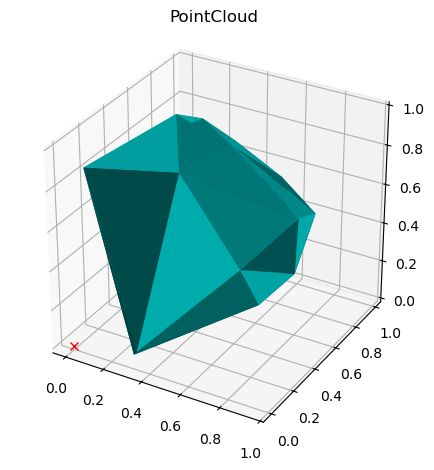

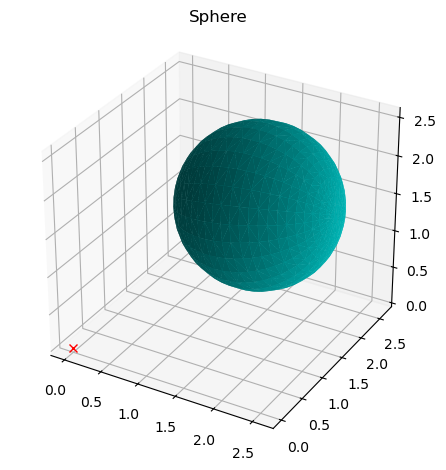

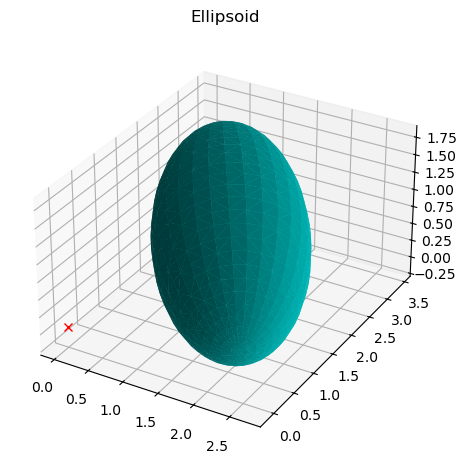

In [2]:
from scipy.spatial.transform import Rotation, RigidTransform
from mupt.geometry.transforms.rigid import random_rigid_transformation


for shape in shapes:
    shape.rigidly_transform(
        random_rigid_transformation(translation_bound=2.0)
    )
    ax = visualize_shape(shape, grid=True, color='c')
    ax.plot(0, 0, 0, 'rx') # show the origin for reference

### Point Clouds as conformers
Given a molecule, one can natively encode it's atomic positions with PointCloud shapes

[21:24:39] UFFTYPER: Unrecognized atom type: *_ (0)
[21:24:39] UFFTYPER: Unrecognized atom type: *_ (8)


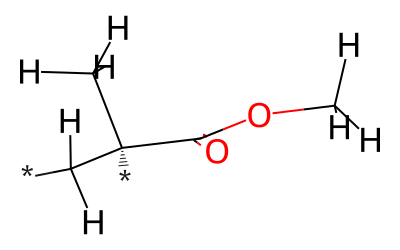

17


In [3]:
from rdkit import Chem
from rdkit.Chem.AllChem import EmbedMolecule

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.molSize = (400, 250)


smi =  '*[C@](C)(C(=O)OC)C*' # PMMA middle repeat unit
mol = Chem.MolFromSmiles(smi, sanitize=True)
mol = Chem.AddHs(mol)

conf_idx : int = EmbedMolecule(mol)
assert conf_idx != -1
display(mol)
print(mol.GetNumAtoms())

PointCloud(shape=(17, 3))


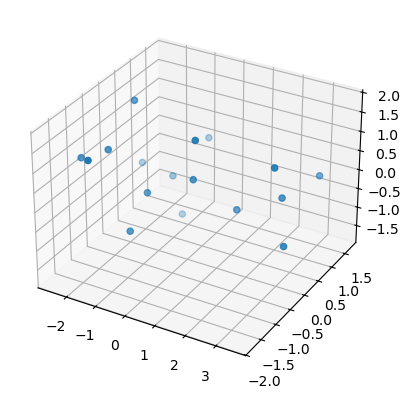

In [4]:
import matplotlib.pyplot as plt


conformer = PointCloud(mol.GetConformer(0).GetPositions())
print(conformer)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection' : '3d'})
_ = ax.scatter(*conformer.positions.T)

### Cylinder (WIP)

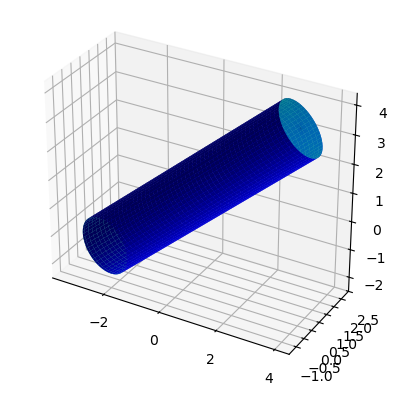

In [5]:
## Cylinder (WIP)
n_r, n_theta = 100, 200
R : float = 1.0
L : float = 8.0

# calculate cylinder wall coordinates
r, theta = np.mgrid[0.0:R:n_r*1j, 0.0:2*np.pi:n_theta*1j]
x_cyl = R * np.cos(theta) # fix radius for walls
y_cyl = R * np.sin(theta) # fix radius for walls
z, _ = np.mgrid[-L/2:L/2:n_r*1j, 0.0:2*np.pi:n_theta*1j]

# calculate face coordinates
x_face = r * np.cos(theta) # vary radius and fix Z for caps
y_face = r * np.sin(theta) # vary radius and fix Z for caps
z_face1 = np.full((n_r, n_theta), fill_value=-L/2)
z_face2 = np.full((n_r, n_theta), fill_value=L/2)

# stack XYZ coordinates together
cyl_pos_ref   = np.dstack([x_cyl, y_cyl, z])
face1_pos_ref = np.dstack([x_face, y_face, z_face1])
face2_pos_ref = np.dstack([x_face, y_face, z_face2])

# apply transform to position in space
transform = random_rigid_transformation(centered=False)
cyl_pos = transform.apply(cyl_pos_ref.reshape(-1, 3)).reshape(n_r, n_theta, 3)
face1_pos = transform.apply(face1_pos_ref.reshape(-1, 3)).reshape(n_r, n_theta, 3)
face2_pos = transform.apply(face2_pos_ref.reshape(-1, 3)).reshape(n_r, n_theta, 3)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(*cyl_pos.T  , color='b')
ax.plot_surface(*face1_pos.T, color='c')
ax.plot_surface(*face2_pos.T, color='c')
ax.set_aspect('equal')

## Export Shapes as animated GIFs

MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.


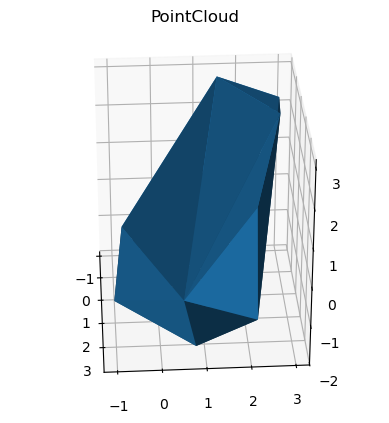

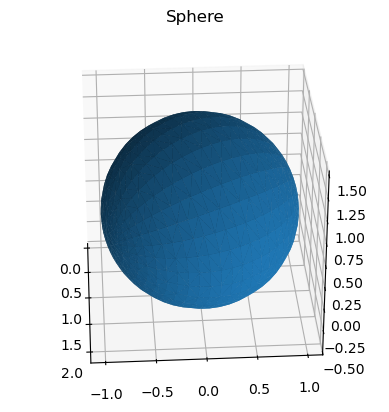

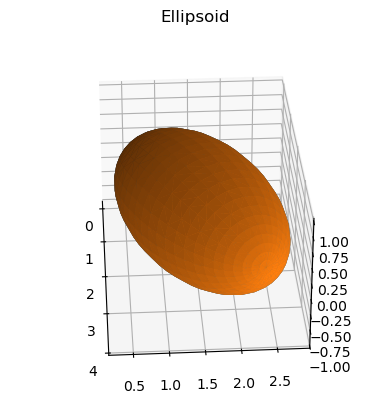

In [6]:
# NBVAL_SKIP
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


shapes_dir = Path('shapes')
shapes_dir.mkdir(parents=True, exist_ok=True)

n_frames : int = 100
loop_time_sec : float = 5
interval = int(loop_time_sec*1000/n_frames) # convert to milliseconds

shapes_animated = [     
    conformer, 
    Sphere(1),
    Ellipsoid.from_components(1, 1, 2),
]
for shape in shapes_animated:
    shape_name : str = type(shape).__name__.lower()
    shape.rigidly_transform(
        random_rigid_transformation(translation_bound=2.0)
    )

    fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'})
    ax.set_title(shape_name)
    anim = FuncAnimation(
        fig,
        func=lambda i : ax.view_init(azim=(i/n_frames)*360),
        init_func=lambda : visualize_shape(shape, ax=ax),
        frames=n_frames,
        interval=interval,
        blit=False,
    )
    anim.save(shapes_dir / f'{shape_name}.gif')